In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df = pd.read_csv('survey_results_shortened.csv')

# Display first few rows and dataset info
print("Data shape:", df.shape)
df.head()

Data shape: (47723, 149)


,MainBranch,Age,MaxAge,AgeNum,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,i am a developer by profession,25-34 years old,34.0,29.0,master's degree,employed,"['caring for dependents (children, elderly, et...",8.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,['vertex ai'],[],[],[],['chatgpt'],[],"[""when i don't trust ai's answers""]","['troubleshooting, profiling, debugging']",61256.0,10.0
1,i am a developer by profession,25-34 years old,34.0,29.0,associate degree,employed,[],2.0,"yes, i am not new to coding but am learning ne...","['books / physical media', 'online courses or ...",...,[],[],[],[],[],[],"[""when i don't trust ai's answers"", 'when i ha...",['all skills. ai is a flop.'],104413.0,9.0
2,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,"independent contractor, freelancer, or self-em...",['none of the above'],10.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,[],[],[],[],"['chatgpt', 'claude code', 'github copilot', '...",[],"[""when i don't trust ai's answers"", 'when i ha...","['understand how things actually work, problem...",53061.0,8.0
3,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,employed,['none of the above'],4.0,"yes, i am not new to coding but am learning ne...","['ai codegen tools or ai-enabled apps', 'other...",...,[],[],[],[],"['chatgpt', 'claude code']",[],"[""when i don't trust ai's answers"", 'when i ha...",[],36197.0,6.0
4,i am a developer by profession,35-44 years old,44.0,39.0,master's degree,"independent contractor, freelancer, or self-em...","['caring for dependents (children, elderly, et...",21.0,"no, i am not new to coding and did not learn n...",[],...,[],[],[],[],[],[],"[""when i don't trust ai's answers""]","['critical thinking, the skill to define the t...",60000.0,7.0


In [26]:
# Zeigt die numerischen Spalten an
df.select_dtypes(include=['int64', 'float64']).info()

# Oder für eine kompakte Übersicht:
print("\nNumerische Spalten:")
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Für eine statistische Übersicht:
print("\nStatistische Zusammenfassung:")
df.select_dtypes(include=['int64', 'float64']).describe()

<class 'pandas.core.frame.DataFrame'>
Index: 18373 entries, 0 to 47620
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MaxAge               18373 non-null  float64
 1   AgeNum               18373 non-null  float64
 2   WorkExp              17909 non-null  float64
 3   YearsCode            18281 non-null  float64
 4   RemoteCategoryNum    16251 non-null  float64
 5   TechEndorse_1        17421 non-null  float64
 6   TechEndorse_2        17421 non-null  float64
 7   TechEndorse_3        17421 non-null  float64
 8   TechEndorse_4        17421 non-null  float64
 9   TechEndorse_5        17421 non-null  float64
 10  TechEndorse_6        17421 non-null  float64
 11  TechEndorse_7        17421 non-null  float64
 12  TechEndorse_8        17421 non-null  float64
 13  TechEndorse_9        17421 non-null  float64
 14  TechEndorse_13       17421 non-null  float64
 15  TechOppose_1         16769 non-null  floa

,MaxAge,AgeNum,WorkExp,YearsCode,RemoteCategoryNum,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,...,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,ToolCountWork,ToolCountPersonal,CompTotal,ConvertedCompYearly,JobSat
count,18373.000000,18373.000000,17909.000000,18281.000000,16251.000000,17421.000000,17421.000000,17421.000000,17421.000000,17421.000000,...,14286.000000,14286.000000,14286.000000,14286.000000,14286.000000,15594.000000,14075.000000,1.837300e+04,18373.000000,14855.000000
mean,39.426985,34.698906,11.856050,15.730813,0.440834,7.968773,4.028012,4.059641,5.695769,4.074508,...,5.727915,8.490480,8.597088,14.703766,7.932731,12.272861,7.567673,5.887950e+06,58802.349752,7.120162
std,10.214271,9.818909,9.016263,9.958514,0.371638,2.301737,2.236637,2.296943,2.383732,2.417874,...,4.130200,3.560038,3.633998,1.840933,4.076572,166.738173,35.077205,8.846872e+07,36852.139257,1.945960
min,24.000000,21.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000e+00,1.000000,0.000000
25%,34.000000,29.000000,5.000000,8.000000,0.000000,7.000000,2.000000,2.000000,4.000000,2.000000,...,2.000000,6.000000,6.000000,15.000000,4.000000,4.000000,3.000000,5.000000e+04,27844.000000,6.000000
50%,34.000000,29.000000,10.000000,13.000000,0.500000,9.000000,4.000000,4.000000,6.000000,4.000000,...,5.000000,9.000000,9.000000,15.000000,8.000000,6.000000,5.000000,8.500000e+04,59167.000000,7.000000
75%,44.000000,39.000000,17.000000,20.000000,0.750000,9.000000,6.000000,6.000000,8.000000,6.000000,...,9.000000,12.000000,12.000000,15.000000,12.000000,10.000000,7.000000,2.400000e+05,87550.000000,8.000000
max,64.000000,59.000000,100.000000,53.000000,1.000000,14.000000,13.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,10000.000000,1000.000000,4.800000e+09,130000.000000,10.000000


Basic Statistics:
             MaxAge     YearsCode       WorkExp        JobSat  \
count  47723.000000  41789.000000  41697.000000  26202.000000   
mean      39.121220     15.963340     12.679234      7.187467   
std       11.074813     10.808035      9.701580      1.994029   
min       24.000000      1.000000      1.000000      0.000000   
25%       34.000000      8.000000      5.000000      6.000000   
50%       34.000000     13.000000     10.000000      8.000000   
75%       44.000000     23.000000     19.000000      8.000000   
max       64.000000     58.000000    100.000000     10.000000   

       ConvertedCompYearly  
count         2.354900e+04  
mean          1.014956e+05  
std           4.638164e+05  
min           1.000000e+00  
25%           3.817100e+04  
50%           7.514700e+04  
75%           1.200000e+05  
max           5.000000e+07  

Missing values per column:
MainBranch                 0
Age                        0
MaxAge                     0
AgeNum              

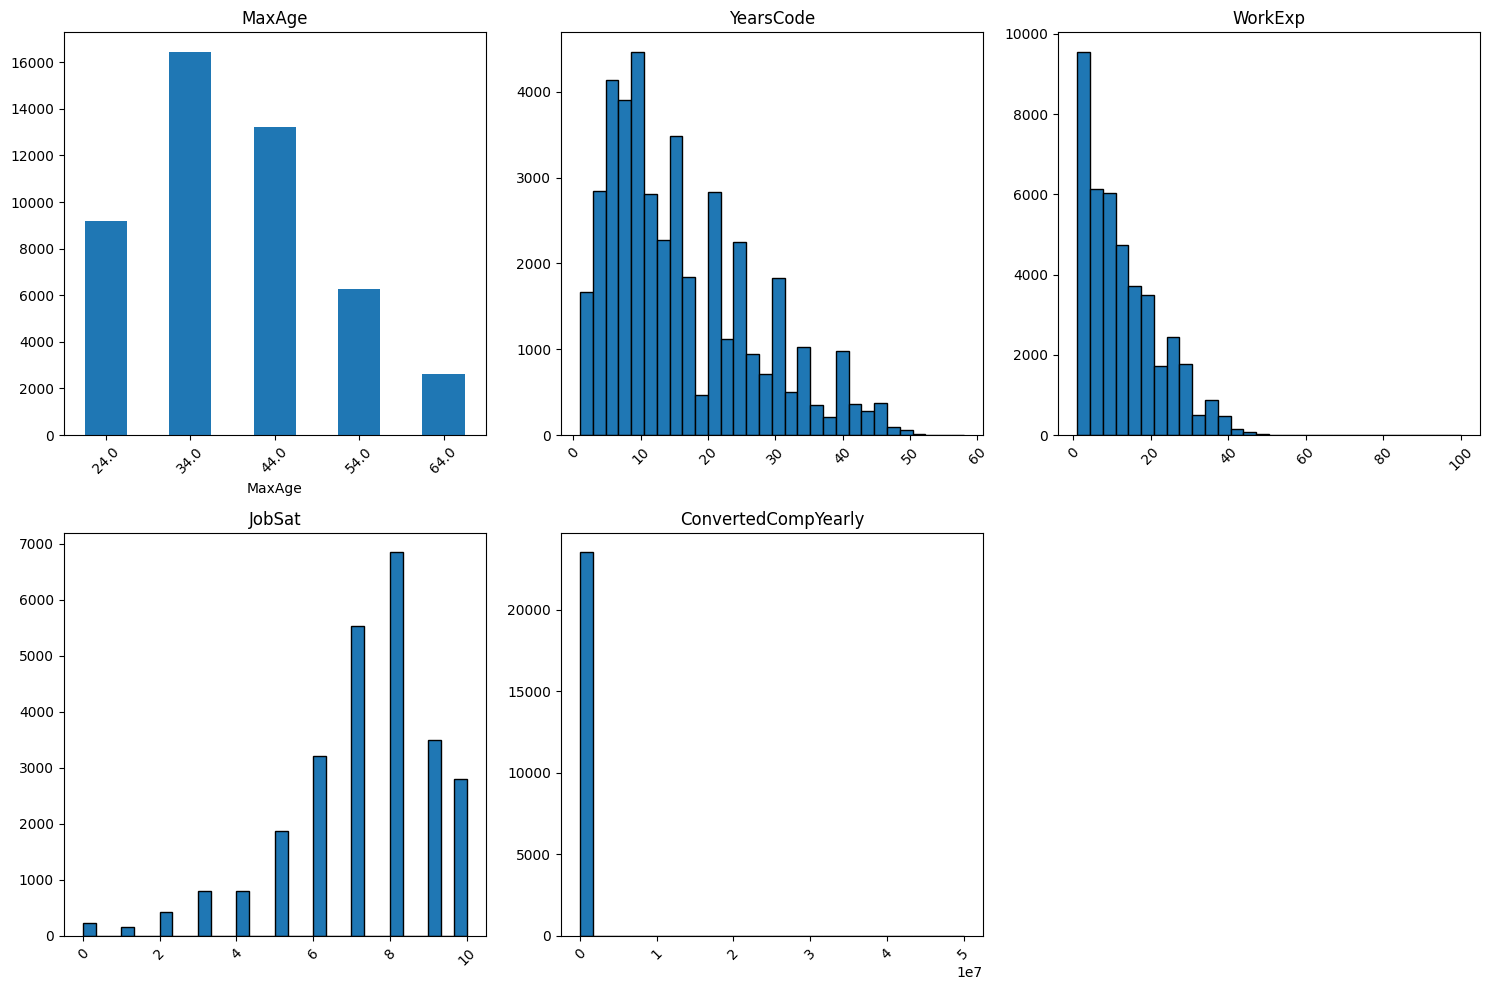

In [5]:
# Basic statistics
print("Basic Statistics:")
print(df[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']].describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Visualize distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly'], 1):
    plt.subplot(2, 3, i)
    if df[col].nunique() > 10:
        plt.hist(df[col].dropna(), bins=30, edgecolor='black')
    else:
        df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Remove top 2% outliers from ConvertedCompYearly
threshold = df['ConvertedCompYearly'].quantile(0.90)
df = df[df['ConvertedCompYearly'] <= threshold]

# Remove any remaining missing values
df_clean = df.dropna(subset=['MaxAge', 'YearsCode', 'AgeNum','WorkExp', 'JobSat', 'ConvertedCompYearly', 'RemoteCategoryNum', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'ToolCountWork', 'ToolCountPersonal'])
# Check the shape after cleaning
print("Shape after cleaning:", df_clean.shape)

# Prepare features and target
X = df_clean[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'AgeNum', 'RemoteCategoryNum', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'ToolCountWork', 'ToolCountPersonal']]
y = df_clean['ConvertedCompYearly']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

KeyError: ['AgenNum']

In [40]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Print model coefficients
print("Intercept:", model.intercept_)
print("\nFeature coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Intercept: 42208.42139608463

Feature coefficients:
MaxAge: 4037.91
YearsCode: 5040.13
WorkExp: -790.25
JobSat: 1565.53
RemoteCategoryNum: -454.80
TechEndorse_1: 1498.25
TechEndorse_2: -814.52
TechEndorse_3: -1483.07
TechEndorse_4: 777.81
TechEndorse_5: -1262.21
TechEndorse_6: -578.39
TechEndorse_7: 121.48
TechEndorse_8: -856.67
TechEndorse_9: -671.43
TechEndorse_13: -962.66
TechOppose_1: 2703.89
TechOppose_2: -46.01
TechOppose_3: -284.12
TechOppose_5: -534.76
TechOppose_7: -304.60
TechOppose_9: -681.97
TechOppose_11: -1055.39
TechOppose_13: -495.24
TechOppose_16: -624.28
ToolCountWork: -42.05
ToolCountPersonal: 449.79



Training Set Evaluation:
Mean Squared Error: 524606325.53
Root Mean Squared Error: 22904.29
R² Score: 0.1496

Test Set Evaluation:
Mean Squared Error: 528844163.27
Root Mean Squared Error: 22996.61
R² Score: 0.1586


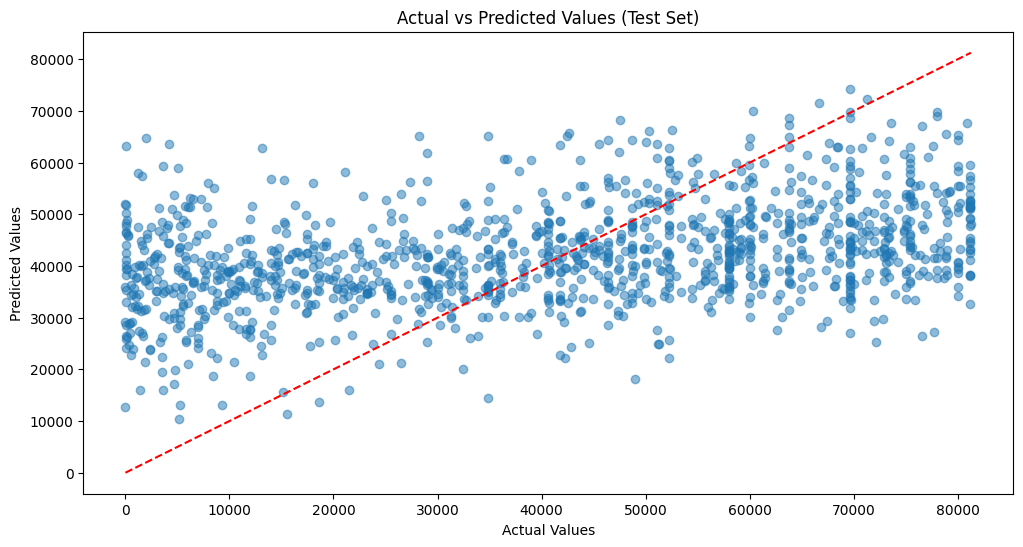

In [41]:
def evaluate_model(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Evaluation:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate on both training and test sets
evaluate_model(y_train, y_pred_train, "Training")
evaluate_model(y_test, y_pred_test, "Test")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Test Set)')
plt.show()

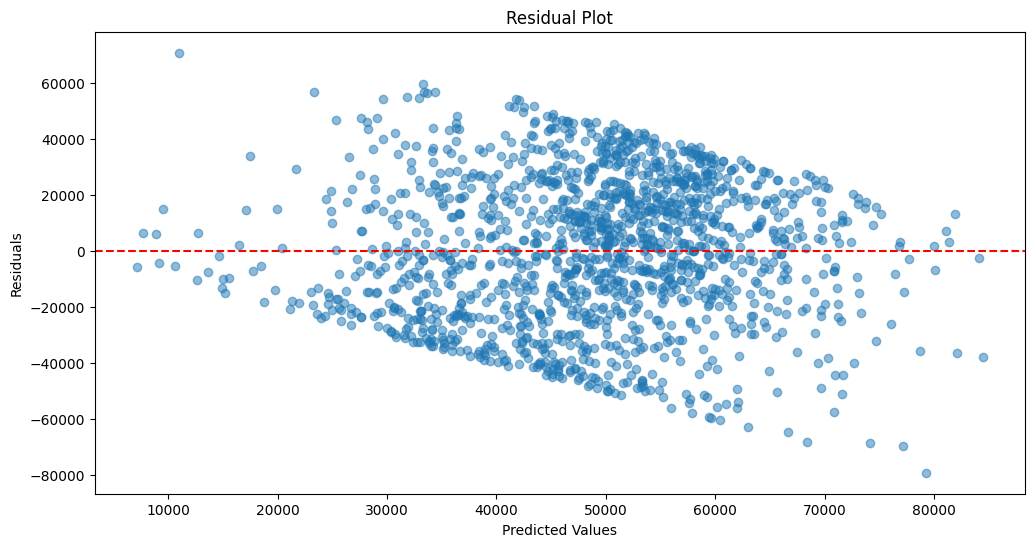

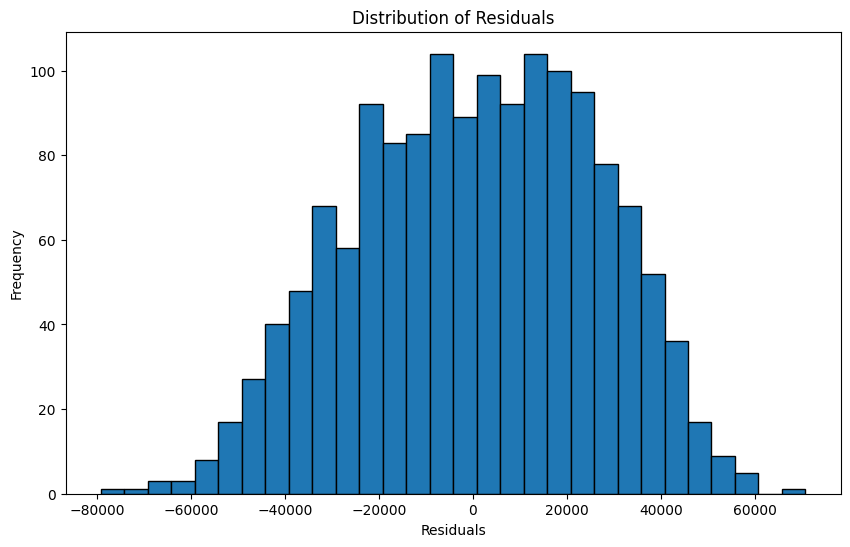

In [34]:
# Calculate residuals
residuals = y_test - y_pred_test

# Plot residuals
plt.figure(figsize=(12, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Check residual distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [35]:
# Remove top 2% outliers from ConvertedCompYearly
threshold = df['ConvertedCompYearly'].quantile(0.98)
df = df[df['ConvertedCompYearly'] <= threshold]

# Remove any remaining missing values
df_clean = df.dropna(subset=['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly'])

# Check the shape after cleaning
print("Shape after cleaning:", df_clean.shape)

# Prepare features and target
X = df_clean[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat']]
y = df_clean['ConvertedCompYearly']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Shape after cleaning: (11483, 149)
Training set size: (9186, 4)
Test set size: (2297, 4)


In [36]:
# Remove top 2% outliers from ConvertedCompYearly
threshold = df['ConvertedCompYearly'].quantile(0.98)
df = df[df['ConvertedCompYearly'] <= threshold]

# Remove any remaining missing values
df_clean = df.dropna(subset=['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly'])

# Check the shape after cleaning
print("Shape after cleaning:", df_clean.shape)

# Prepare features and target
X = df_clean[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat']]
y = df_clean['ConvertedCompYearly']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Shape after cleaning: (11438, 149)
Training set size: (9150, 4)
Test set size: (2288, 4)


In [37]:
# Remove top 2% outliers from ConvertedCompYearly
threshold = df['ConvertedCompYearly'].quantile(0.98)
df = df[df['ConvertedCompYearly'] <= threshold]

# Remove any remaining missing values
df_clean = df.dropna(subset=['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly'])

# Check the shape after cleaning
print("Shape after cleaning:", df_clean.shape)

# Prepare features and target
X = df_clean[['MaxAge', 'YearsCode', 'WorkExp', 'JobSat']]
y = df_clean['ConvertedCompYearly']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Shape after cleaning: (11205, 149)
Training set size: (8964, 4)
Test set size: (2241, 4)


In [38]:
# Get feature importance (absolute value of coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_)
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length